# Planejamento Experimental

## Carregando Resultados

In [2]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd()
results_dir = base_dir / "results"

arquivos_resultados = sorted(results_dir.glob("*_resultados.csv"))
arquivos_historico = sorted(results_dir.glob("*_historico.csv"))

df_resultados = pd.concat(
    [pd.read_csv(arquivo) for arquivo in arquivos_resultados],
    ignore_index=True,
) if arquivos_resultados else pd.DataFrame()

df_historico = pd.concat(
    [pd.read_csv(arquivo) for arquivo in arquivos_historico],
    ignore_index=True,
) if arquivos_historico else pd.DataFrame()

# Atalho para usar o dataframe principal nas análises subsequentes
df = df_resultados

df_resultados.head()

,algoritmo,funcao,dim,exec_id,best_f,n_fes,tempo_s
0,ag,sphere,30,1,5.168852e-31,100000,3.5854
1,ag,sphere,30,2,2.023769e-31,100000,3.3984
2,ag,sphere,30,3,1.269372e-30,100000,3.4377
3,ag,sphere,30,4,1.490808e-32,100000,3.5111
4,ag,sphere,30,5,9.431206e-35,100000,3.4807


## Funções de Benchmark

### Unimodais


#### Rosenbrock

##### Tabela de Resultados

In [5]:
resumo_rosenbrock = (
    df_resultados[df_resultados['funcao'] == 'rosenbrock']
    .groupby(['algoritmo', 'dim'], as_index=False)
    .agg(
        mediana=('best_f', 'median'),
        media=('best_f', 'mean'),
        desvio_padrao=('best_f', 'std'),
    )
)

resumo_rosenbrock['media_pm_desvio'] = (
    resumo_rosenbrock['media'].round(6).astype(str)
    + ' ± ' +
    resumo_rosenbrock['desvio_padrao'].round(6).astype(str)
)

resumo_rosenbrock

,algoritmo,dim,mediana,media,desvio_padrao,media_pm_desvio
0,ag,30,5.185658,33.745590,41.202067,33.74559 ± 41.202067
1,ag,50,71.120507,72.653119,53.798990,72.653119 ± 53.79899
2,ag,100,90.416191,118.449532,80.373087,118.449532 ± 80.373087
3,de,30,20.362270,20.261050,1.106676,20.26105 ± 1.106676
4,de,50,100.327372,104.273141,53.635577,104.273141 ± 53.635577
5,de,100,98.410561,112.313171,27.247347,112.313171 ± 27.247347
6,epso,30,73.700635,64.406916,36.100466,64.406916 ± 36.100466
7,epso,50,89.387120,93.825133,46.196664,93.825133 ± 46.196664
8,epso,100,91.513427,92.714383,7.765483,92.714383 ± 7.765483
9,pso,30,10.594934,12.368618,15.530895,12.368618 ± 15.530895


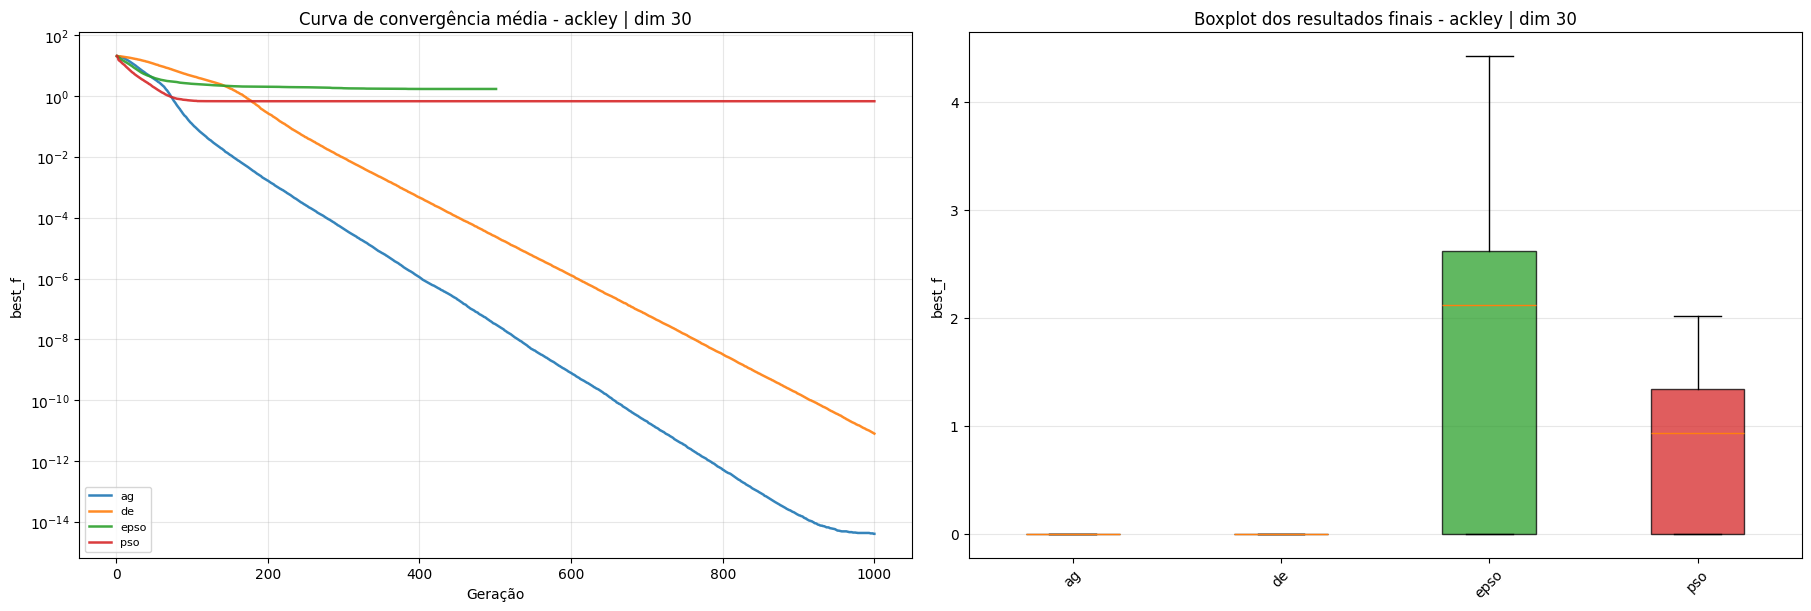

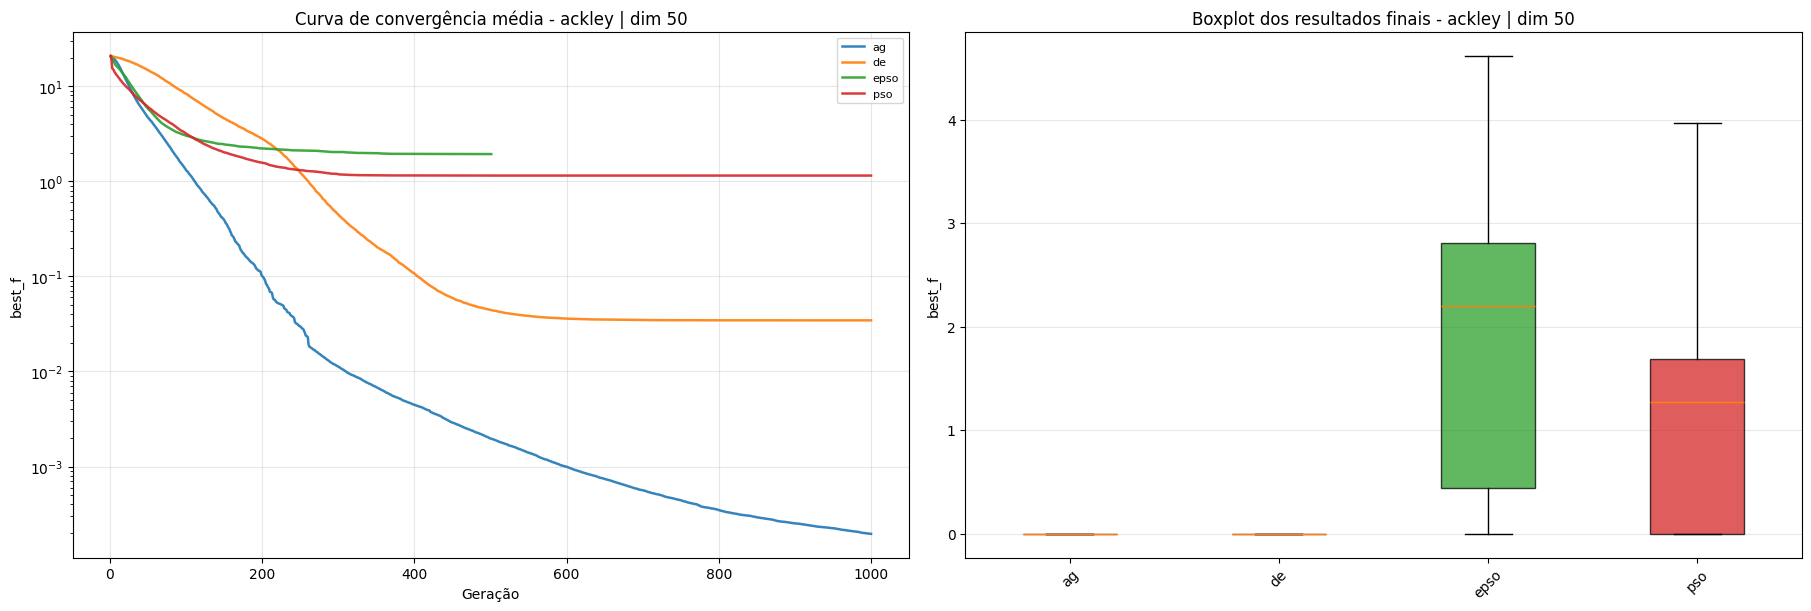

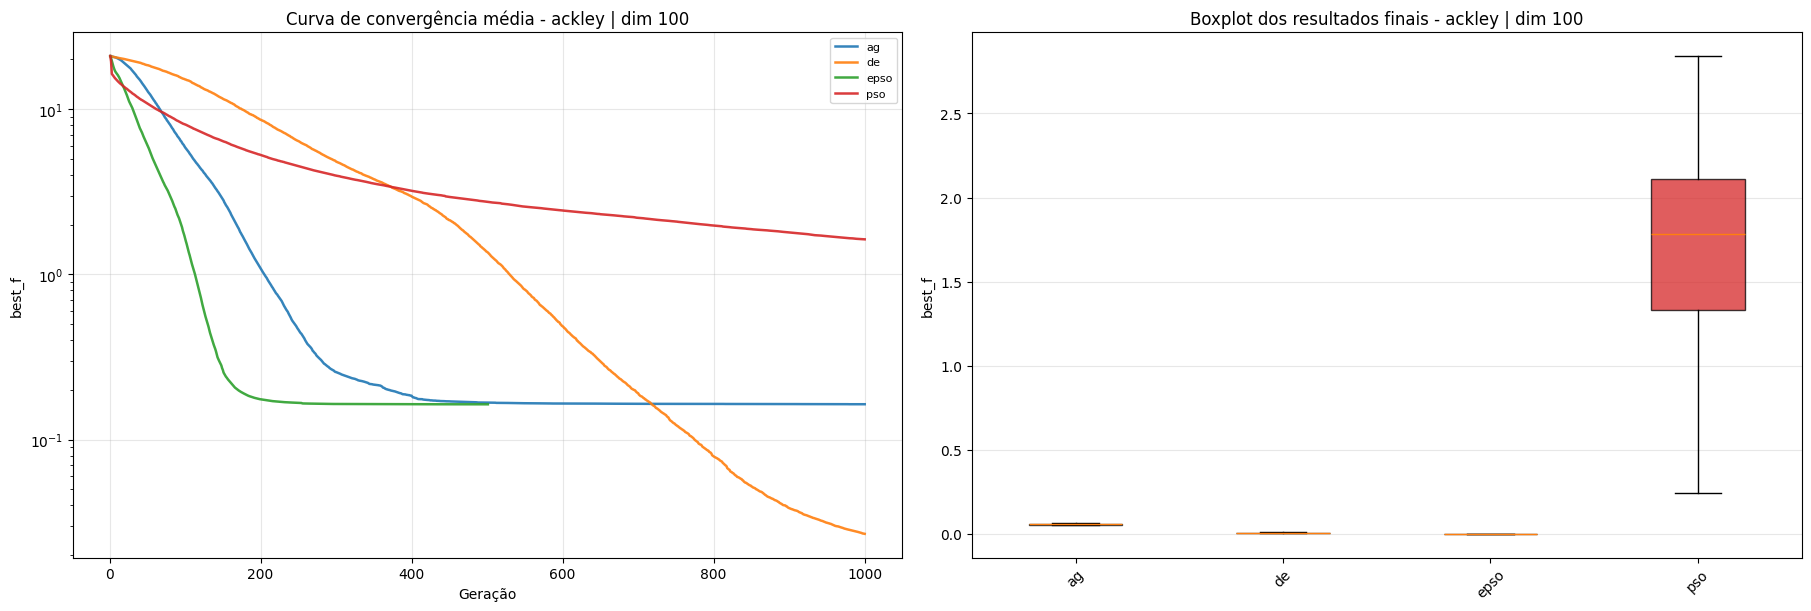

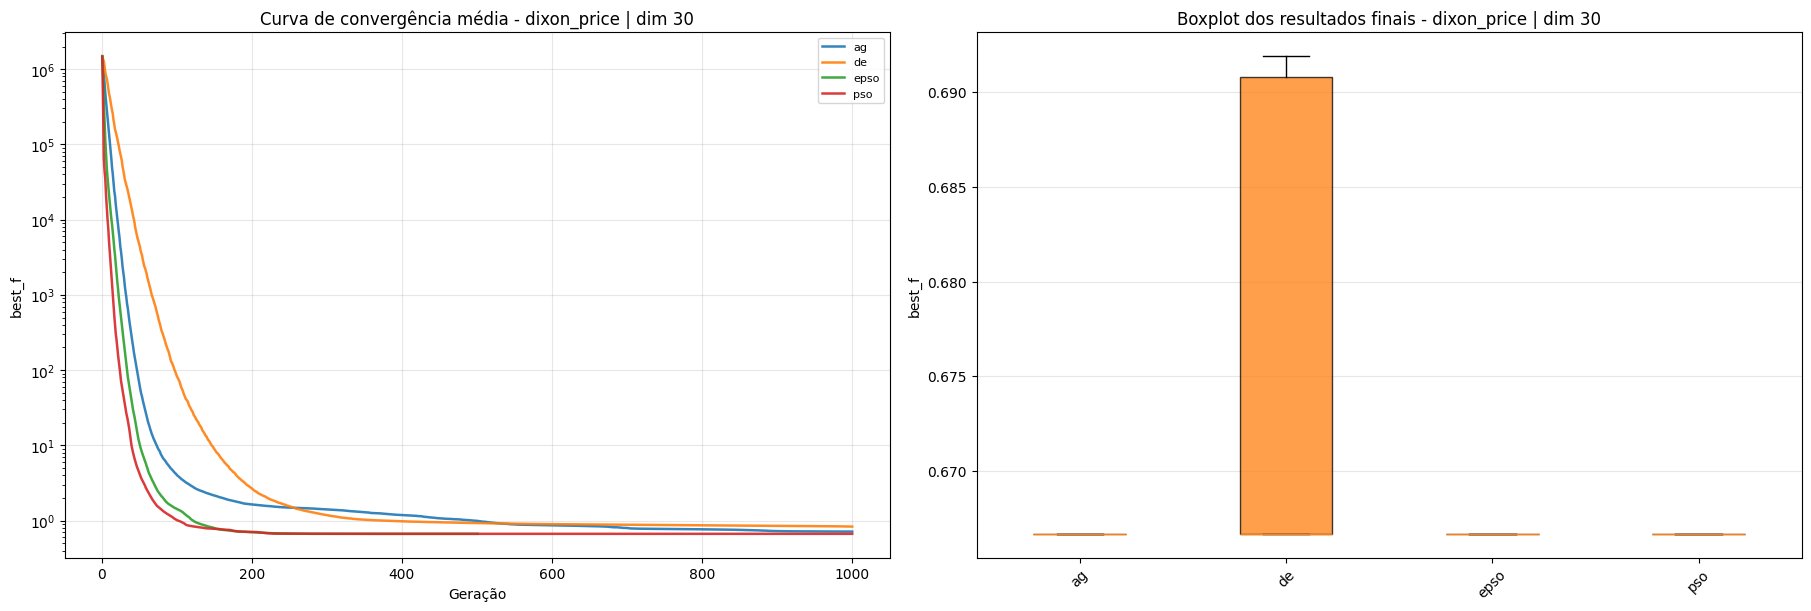

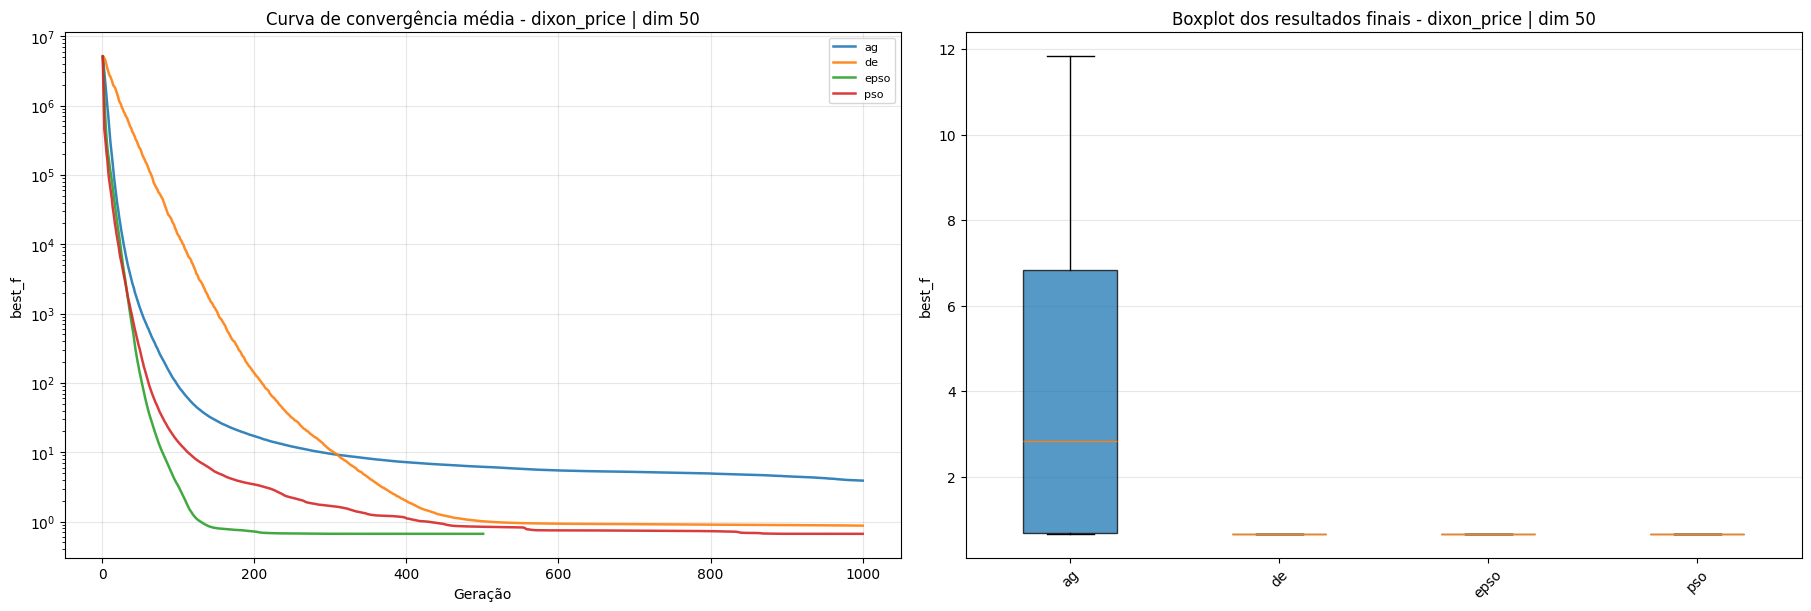

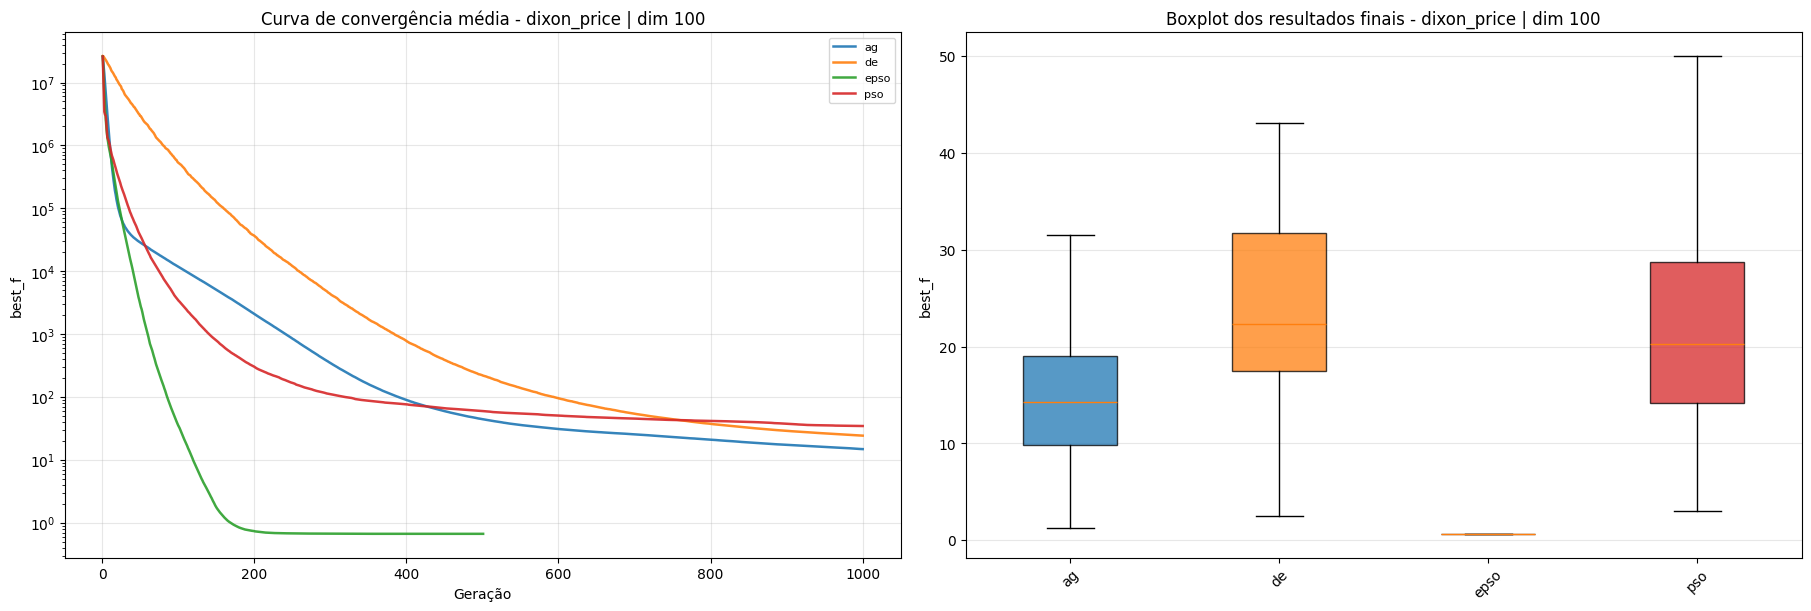

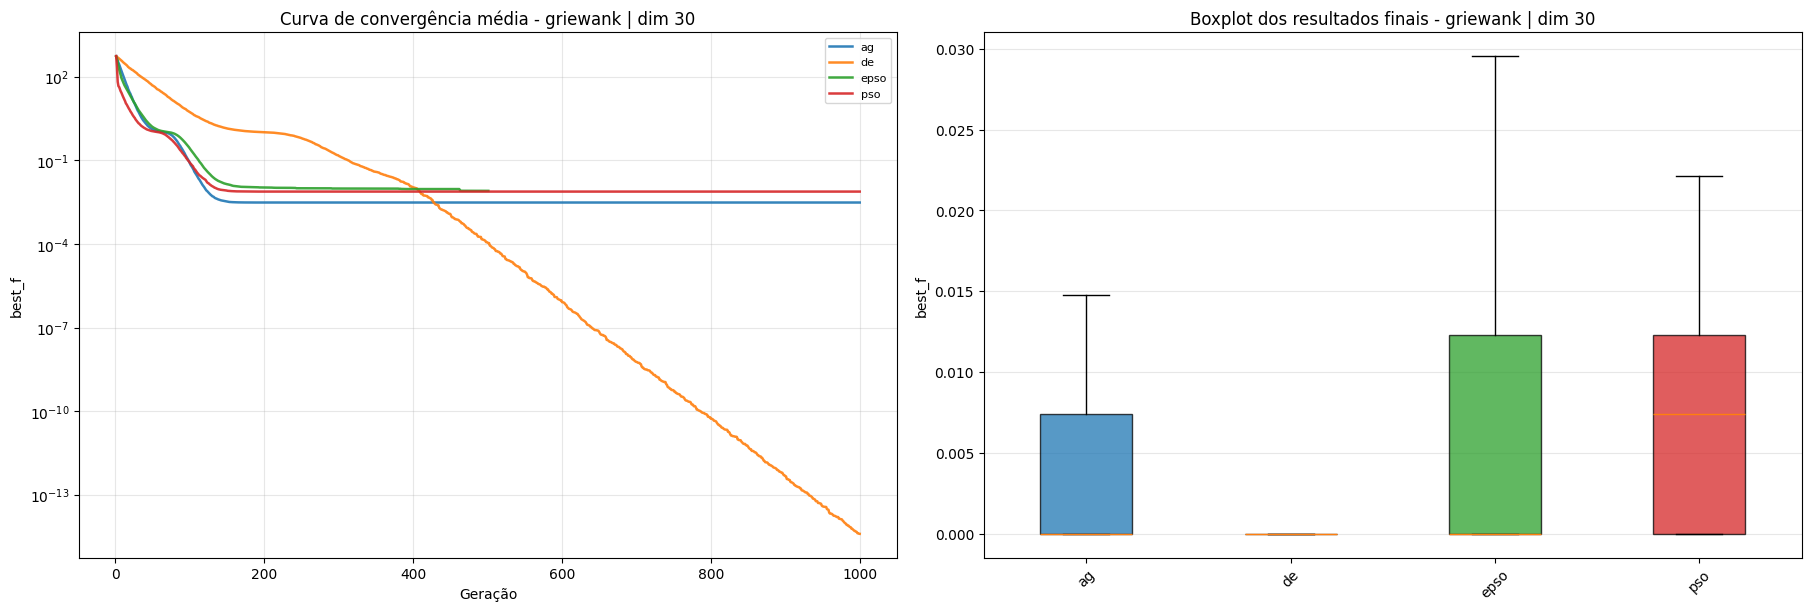

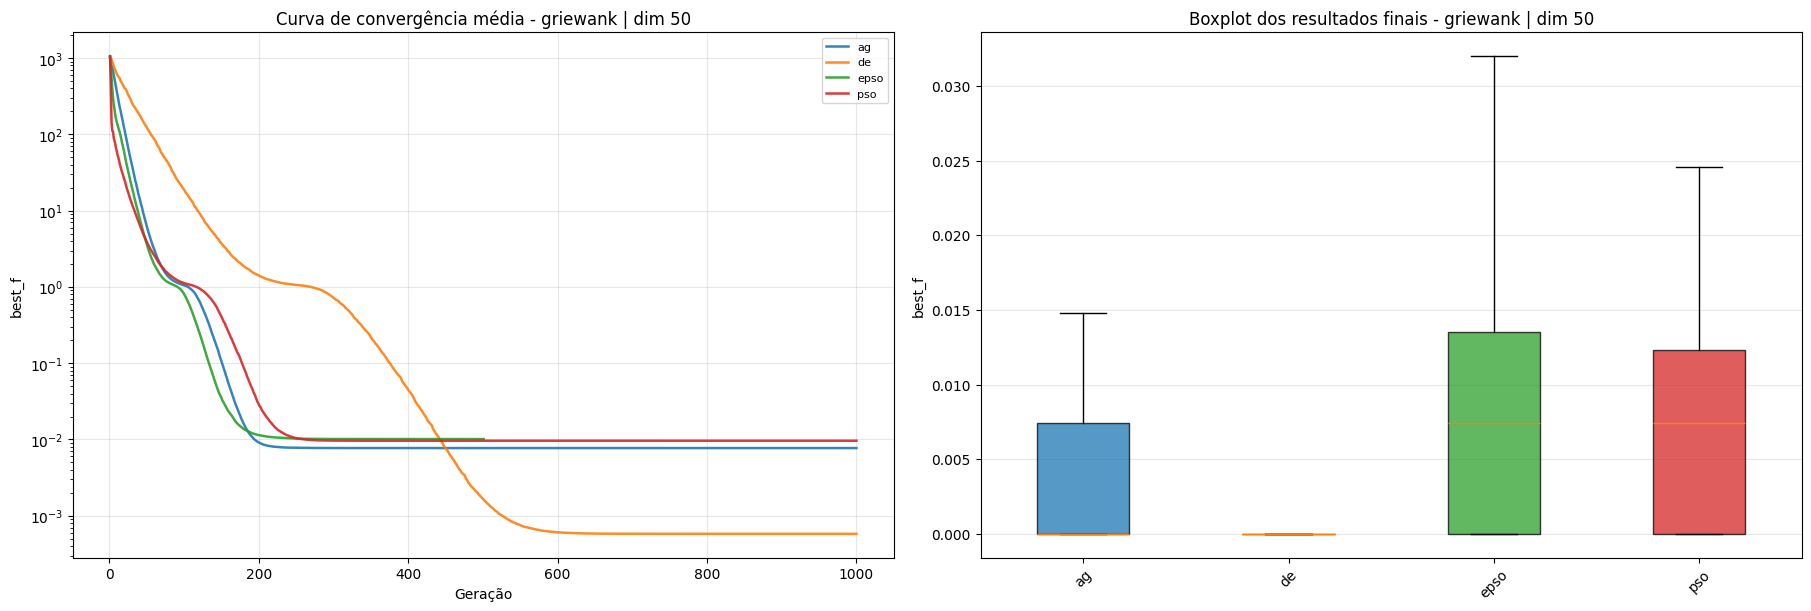

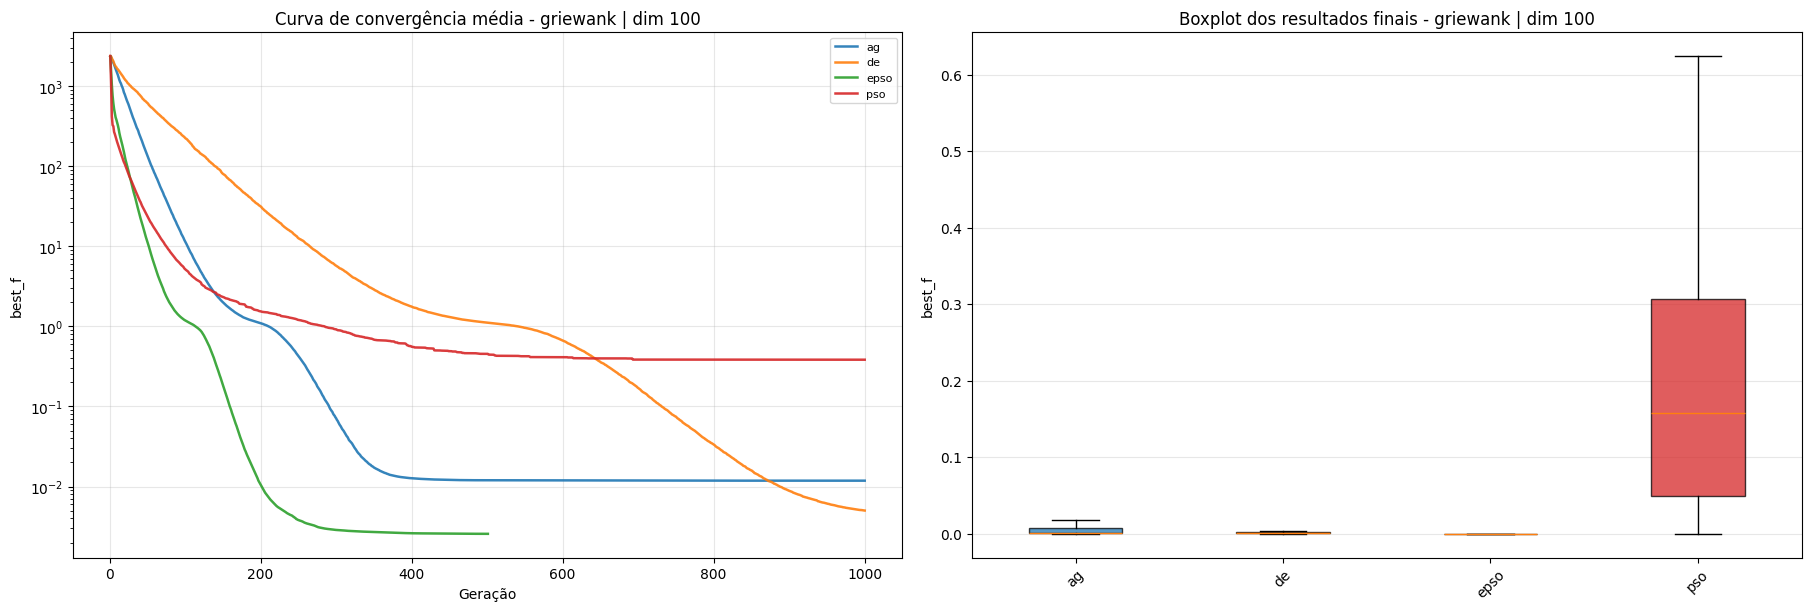

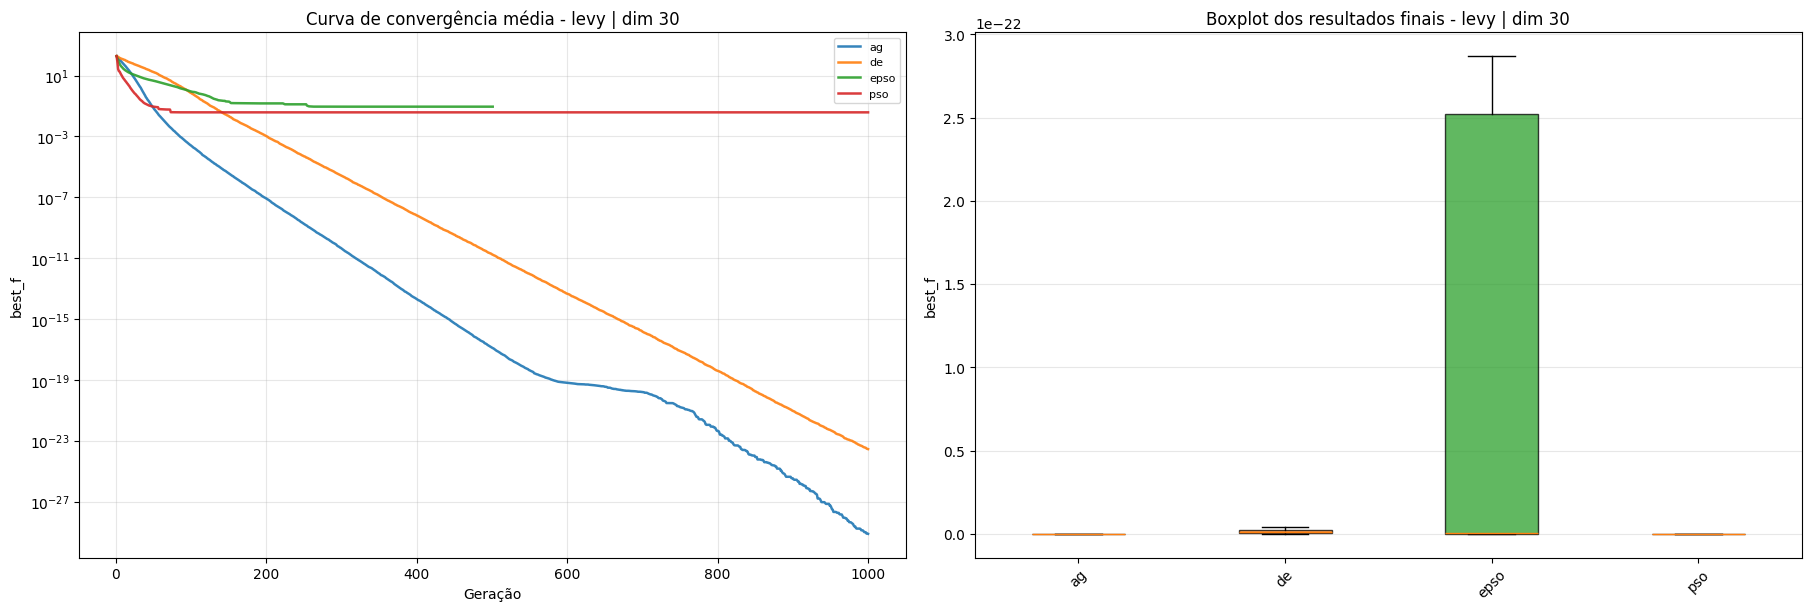

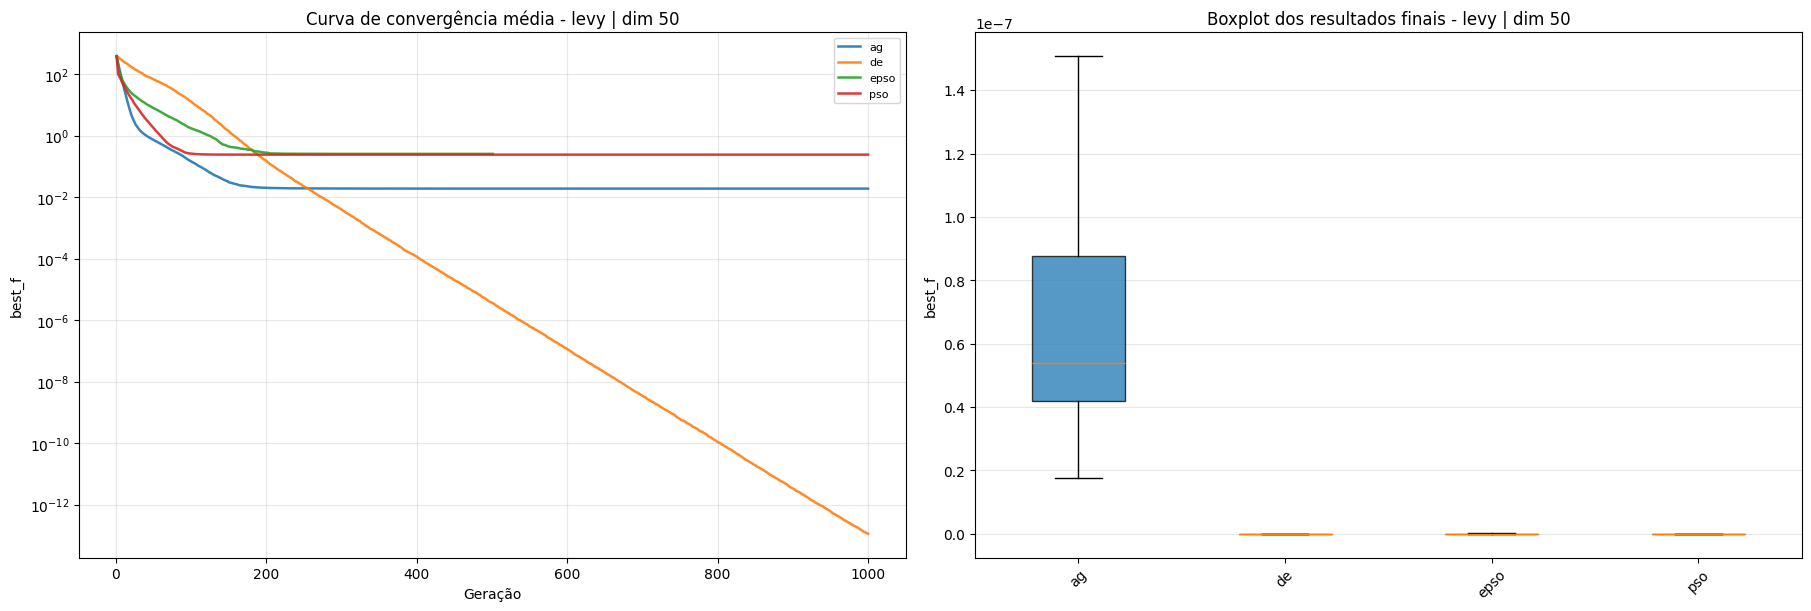

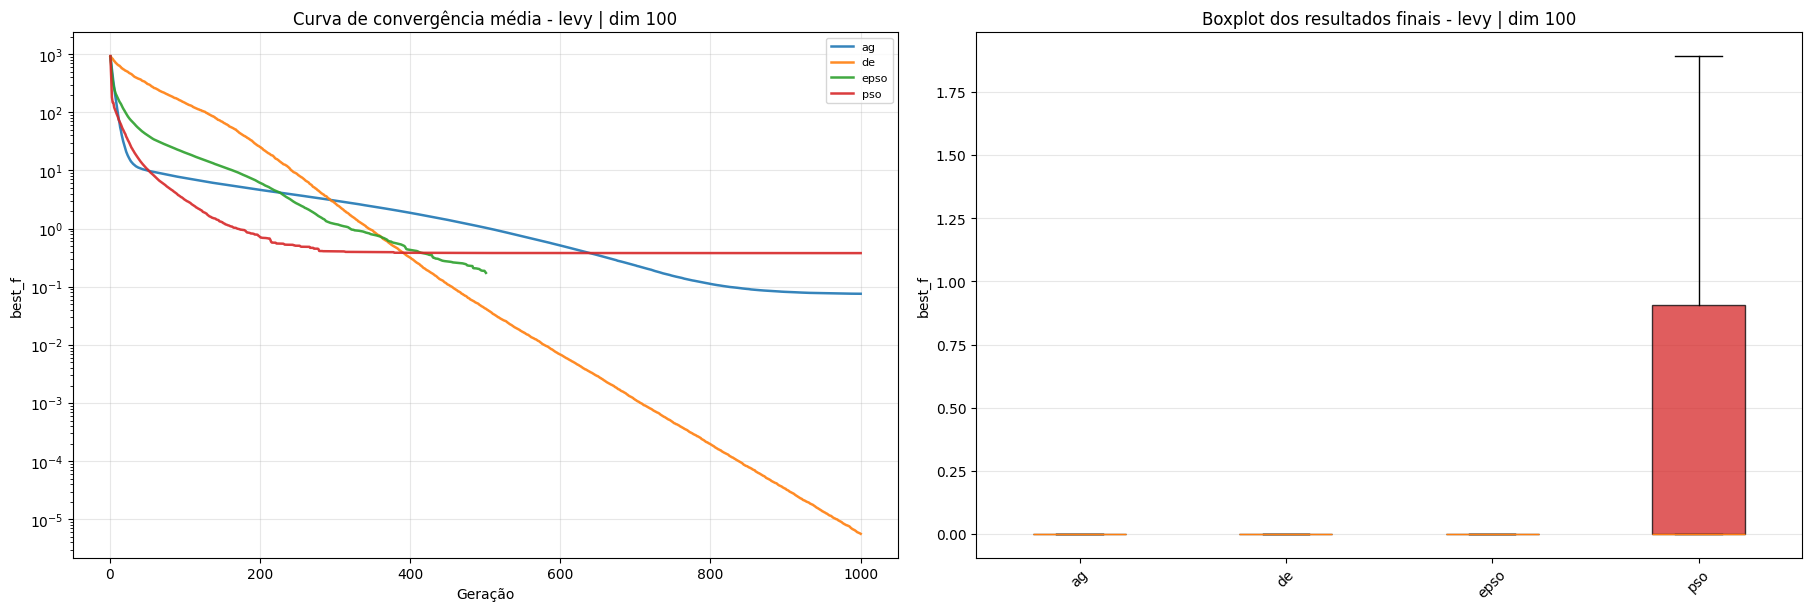

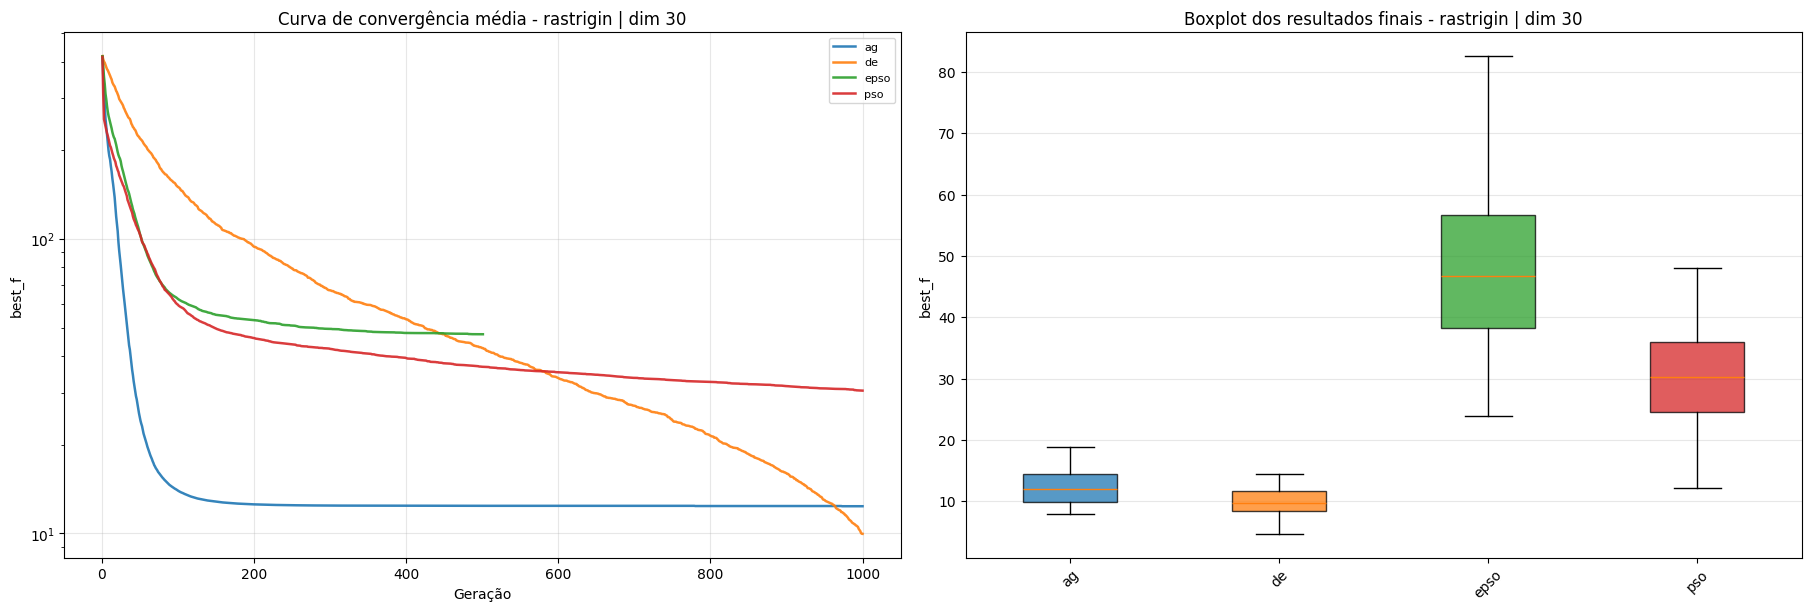

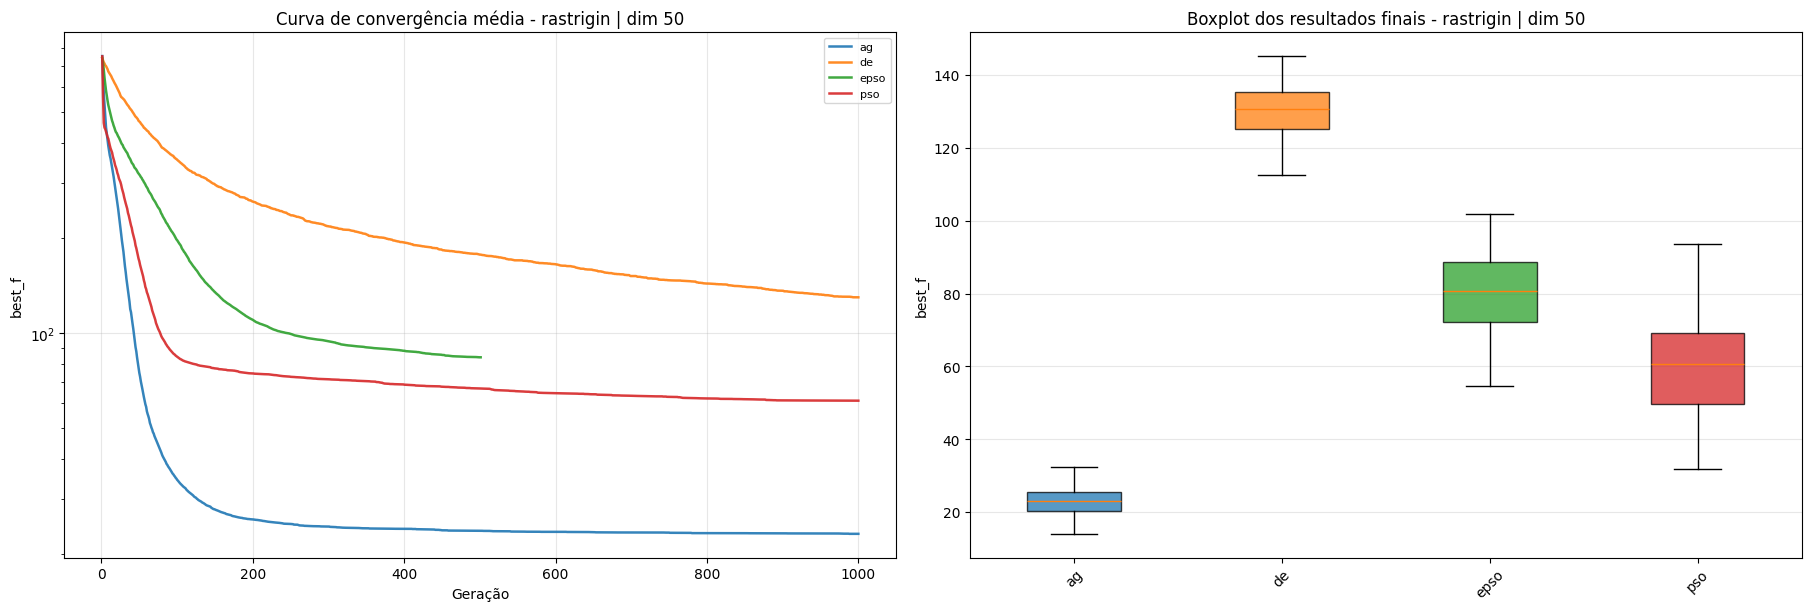

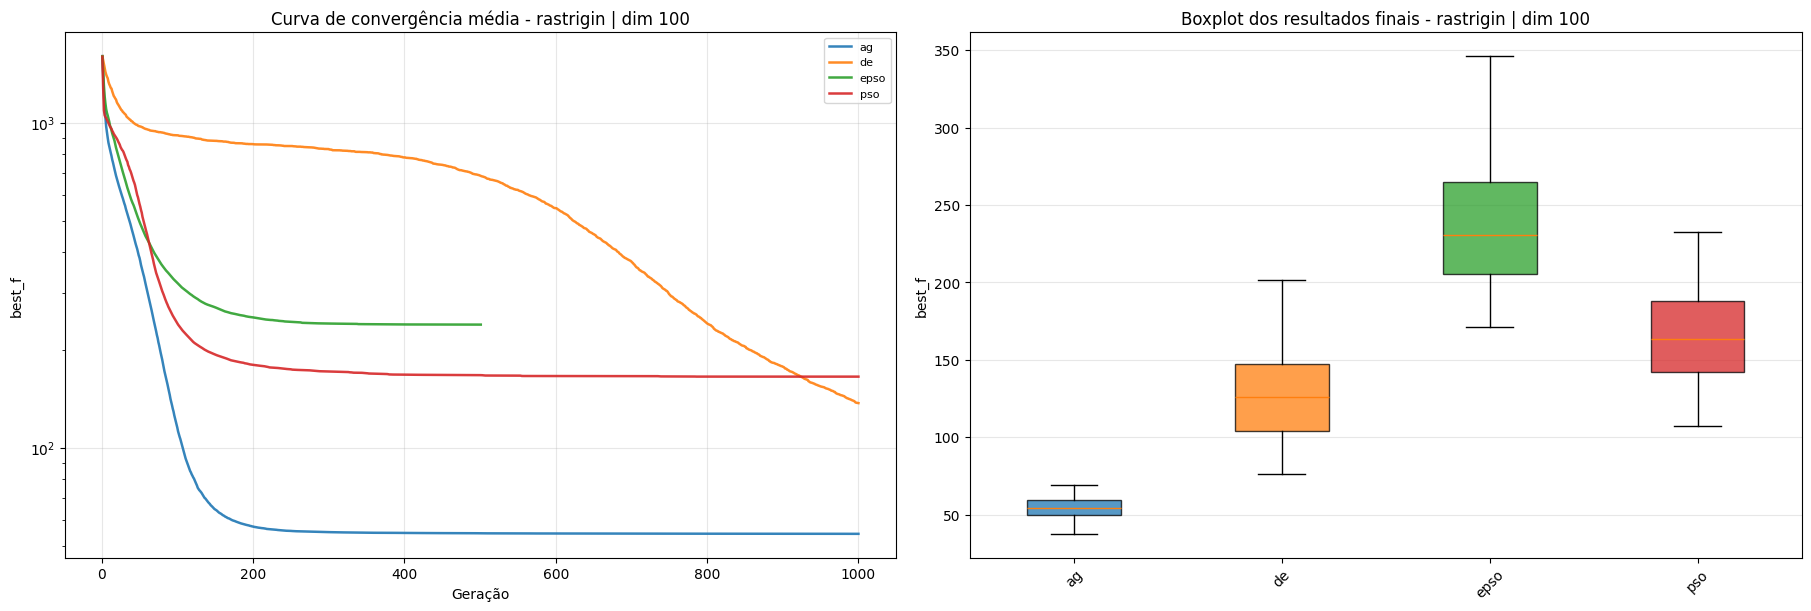

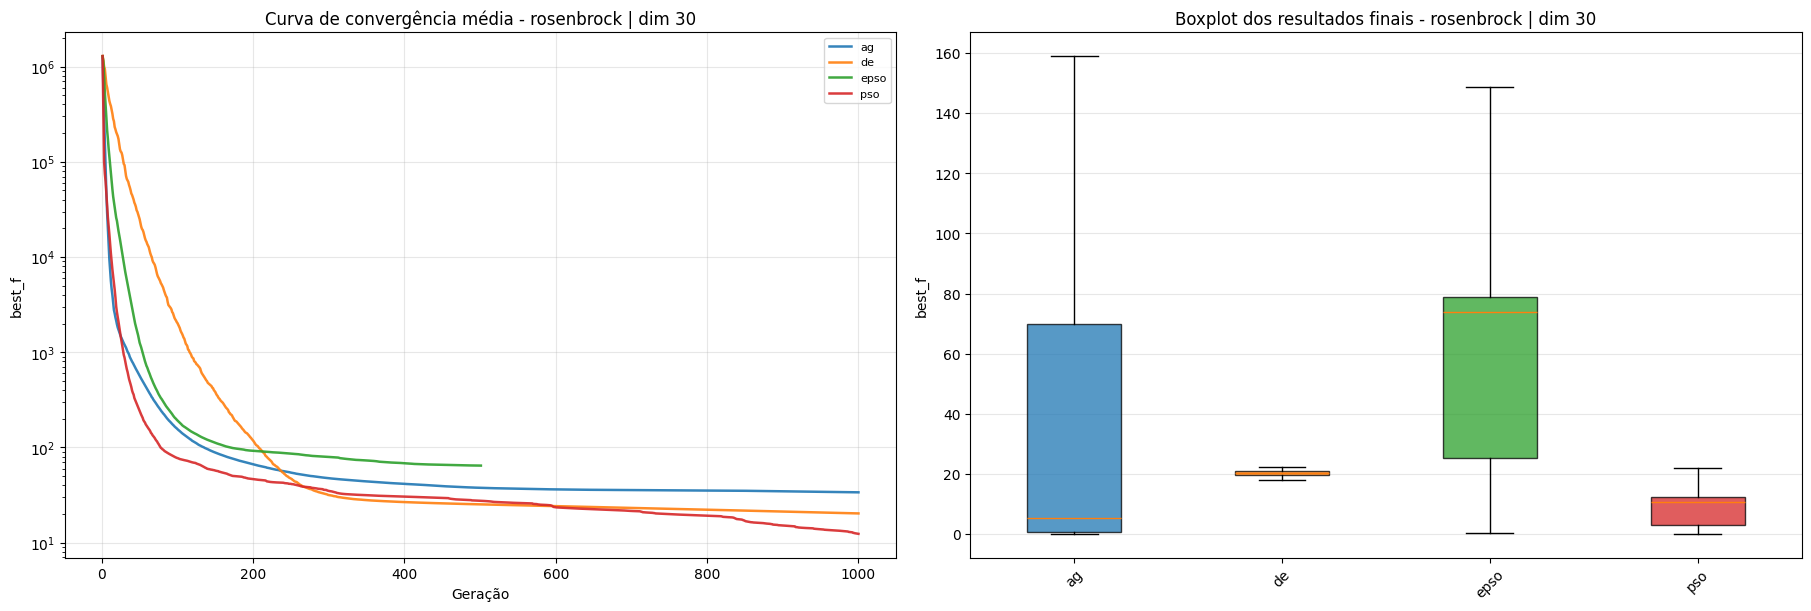

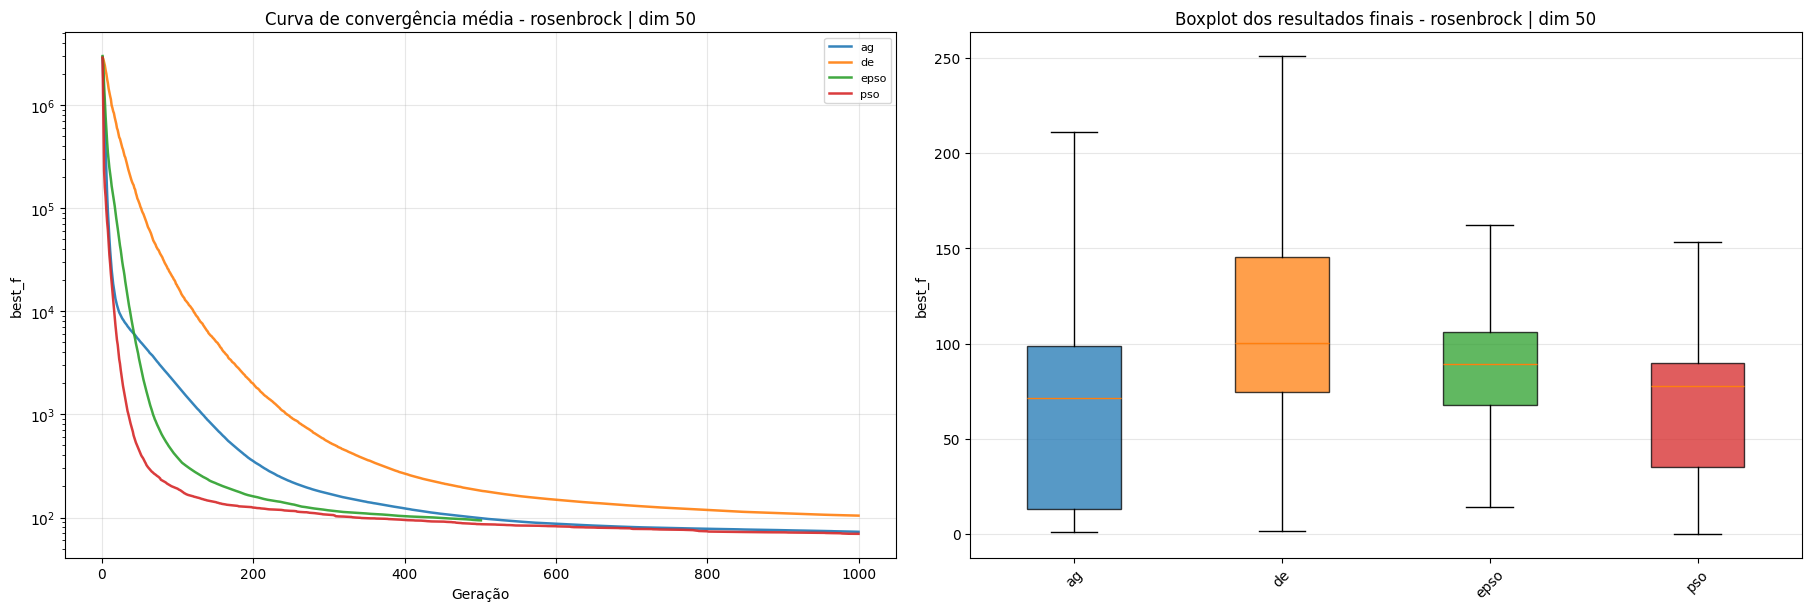

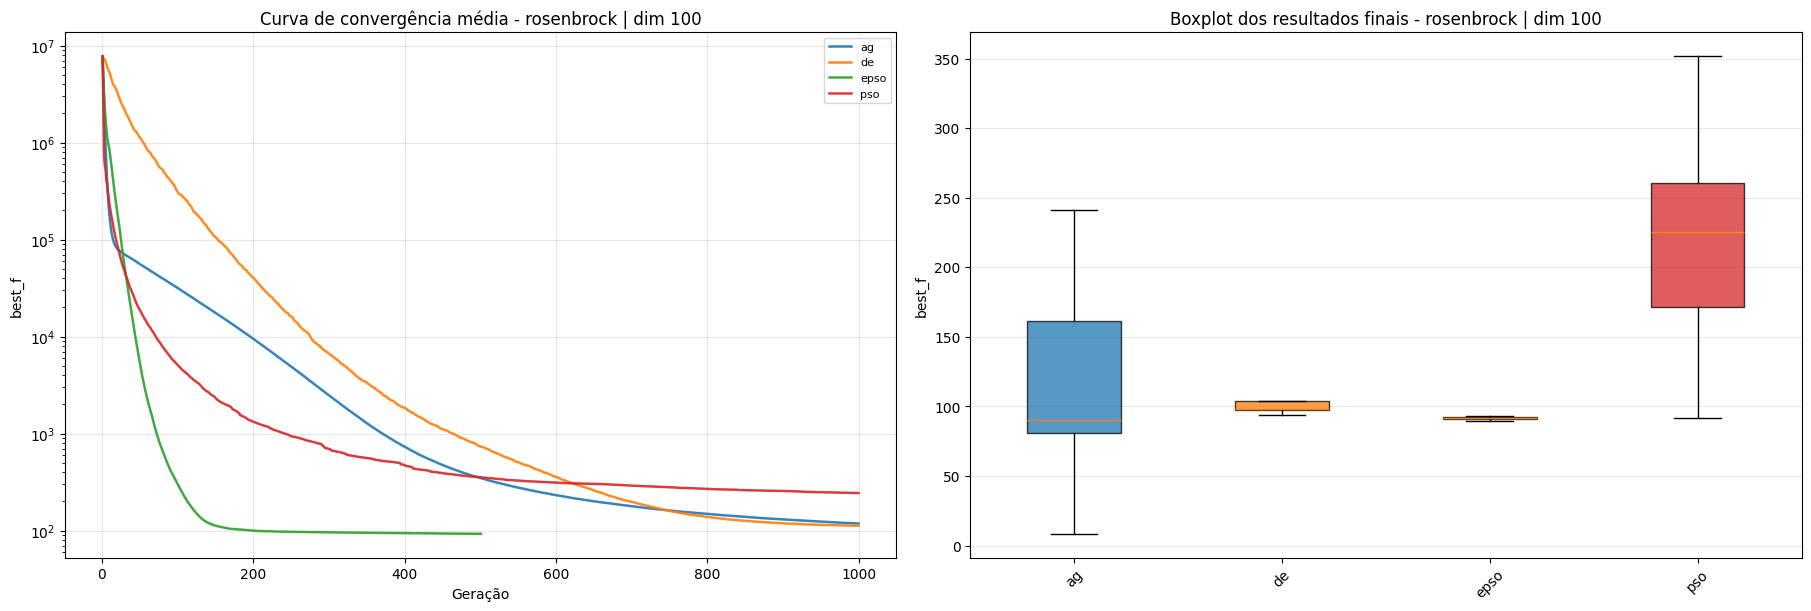

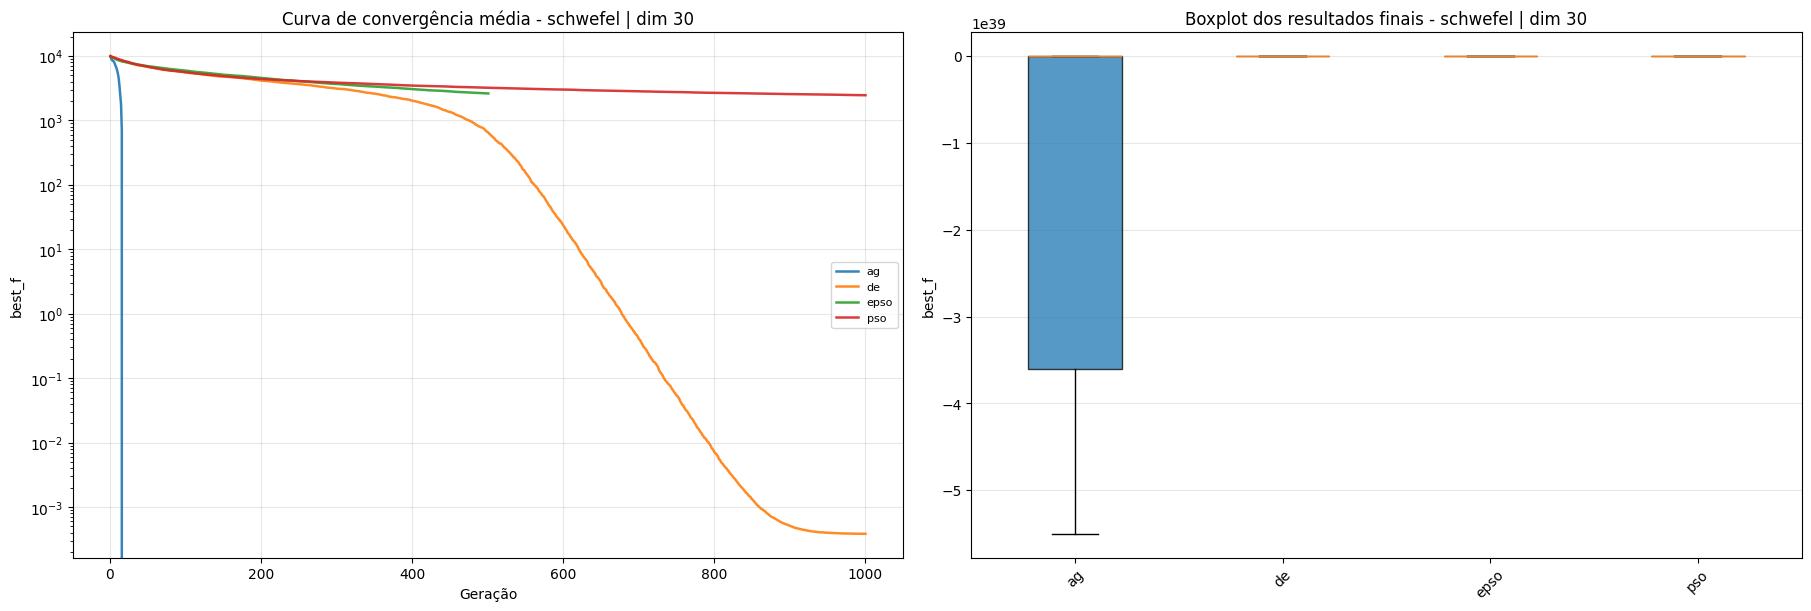

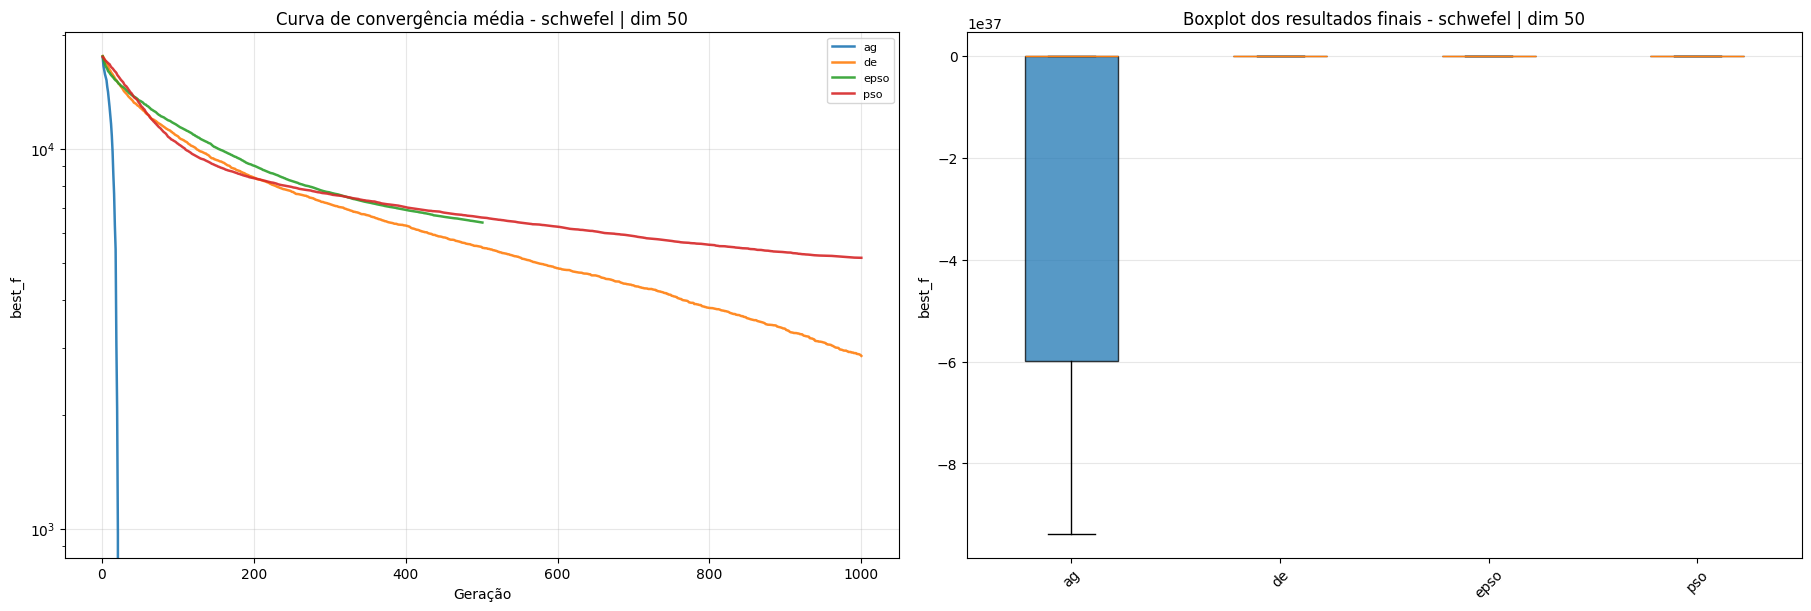

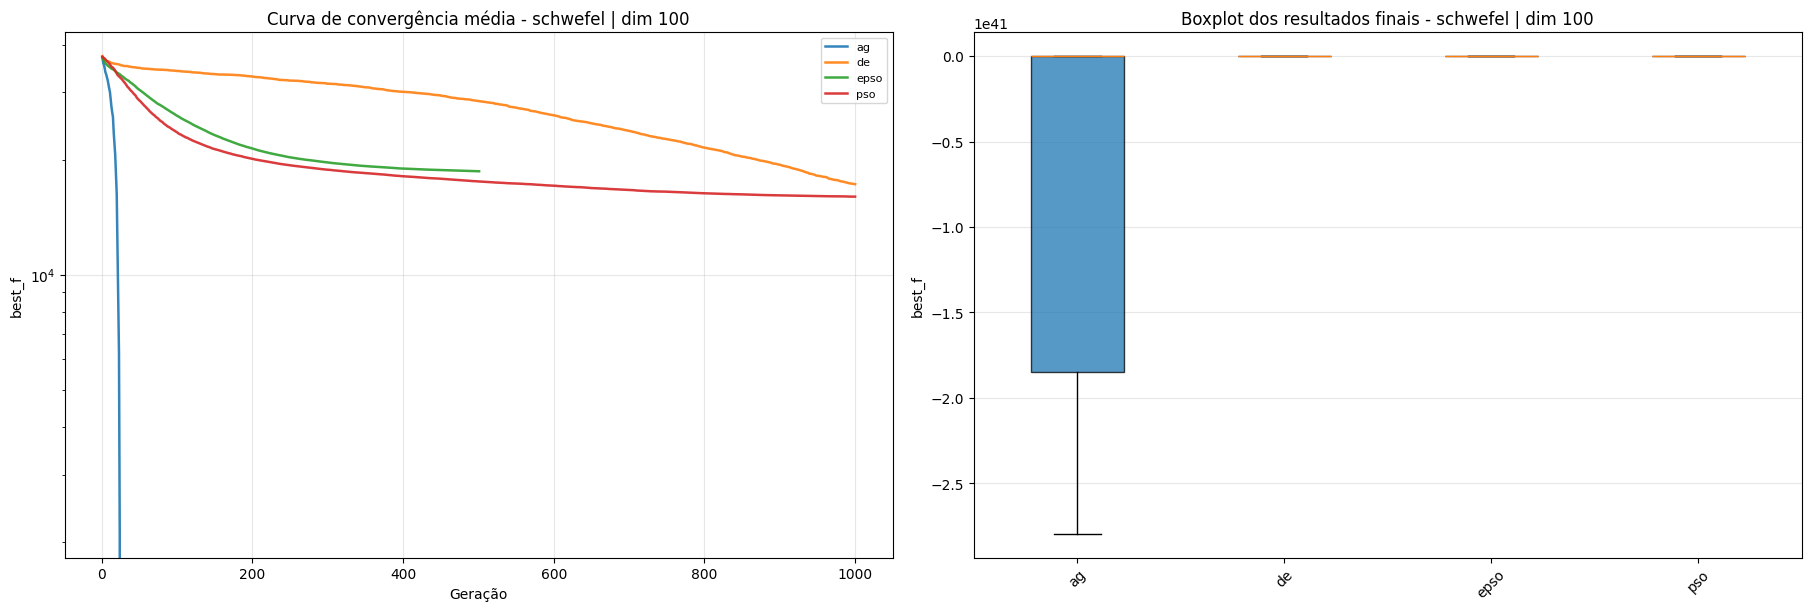

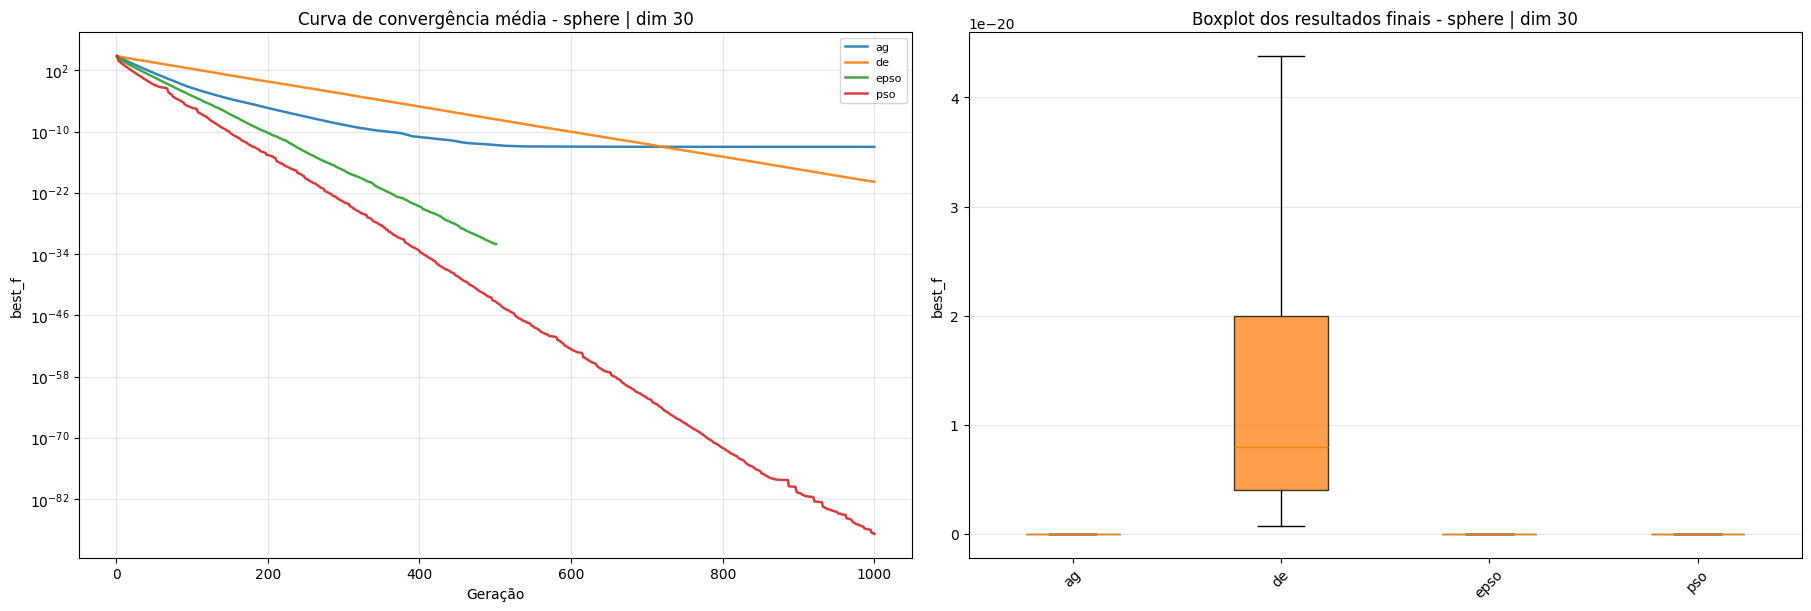

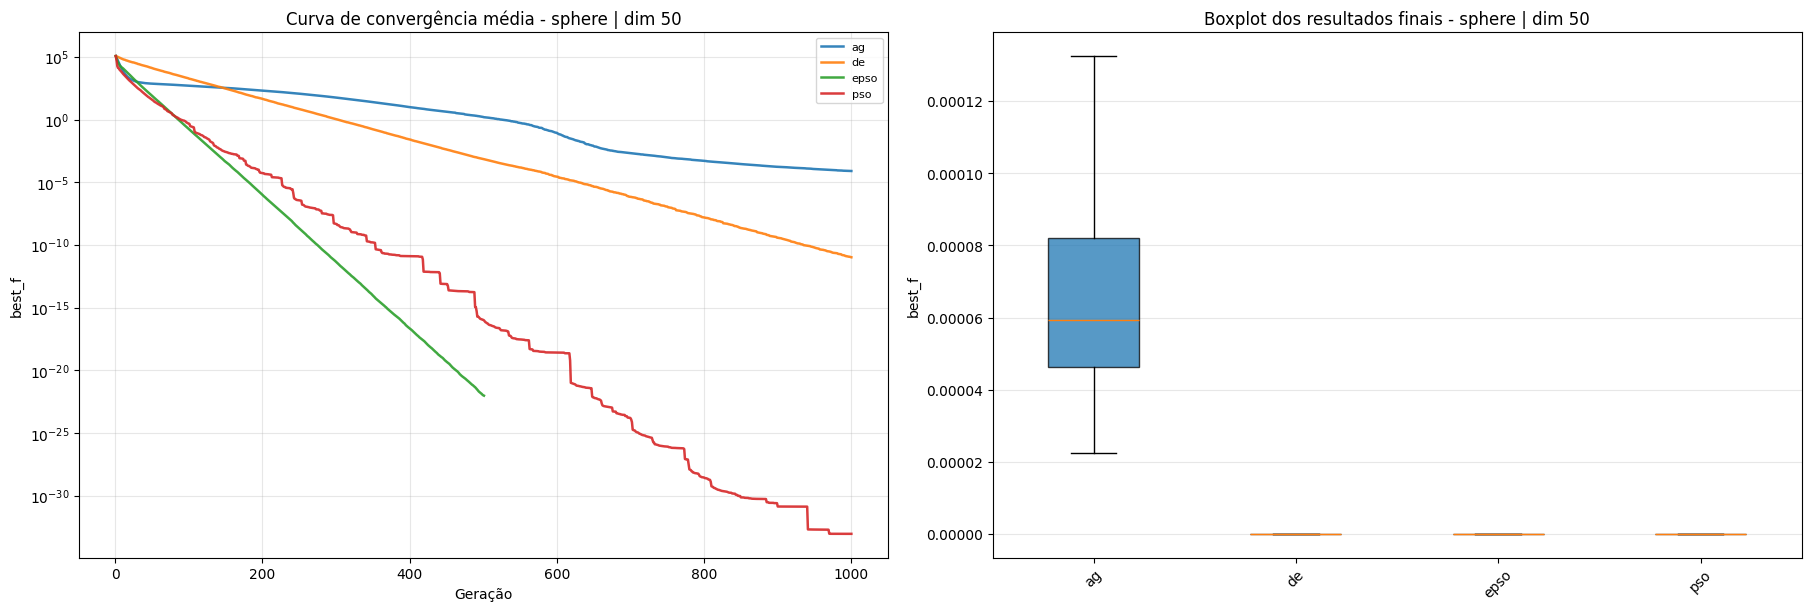

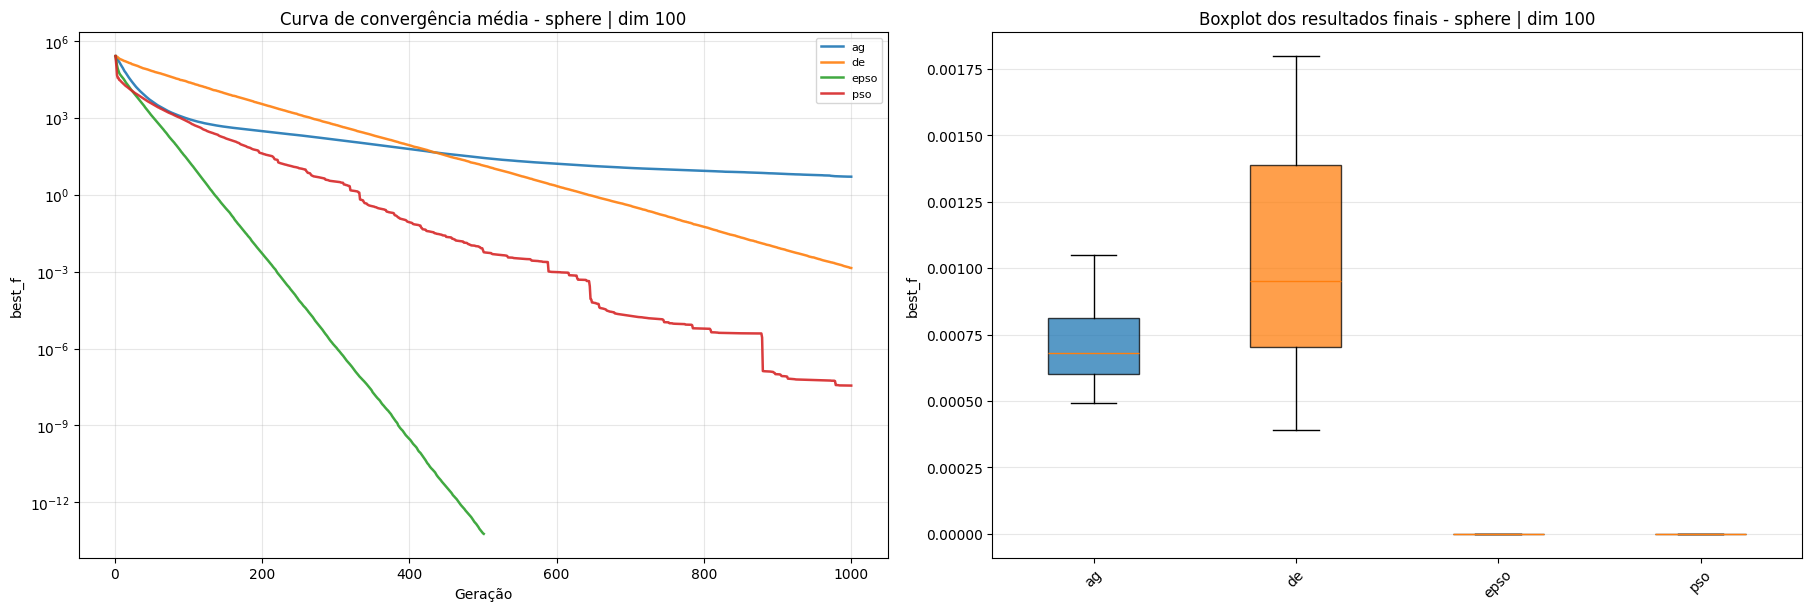

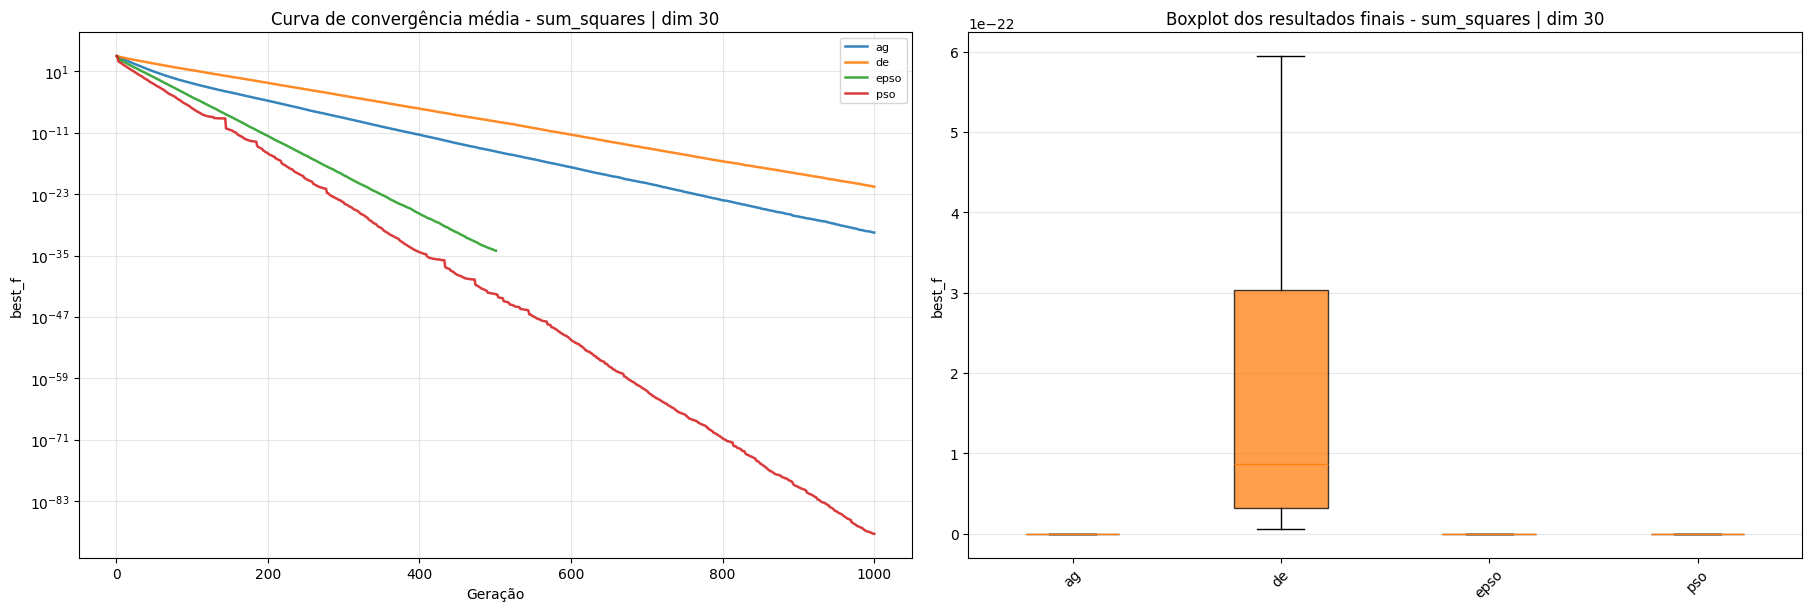

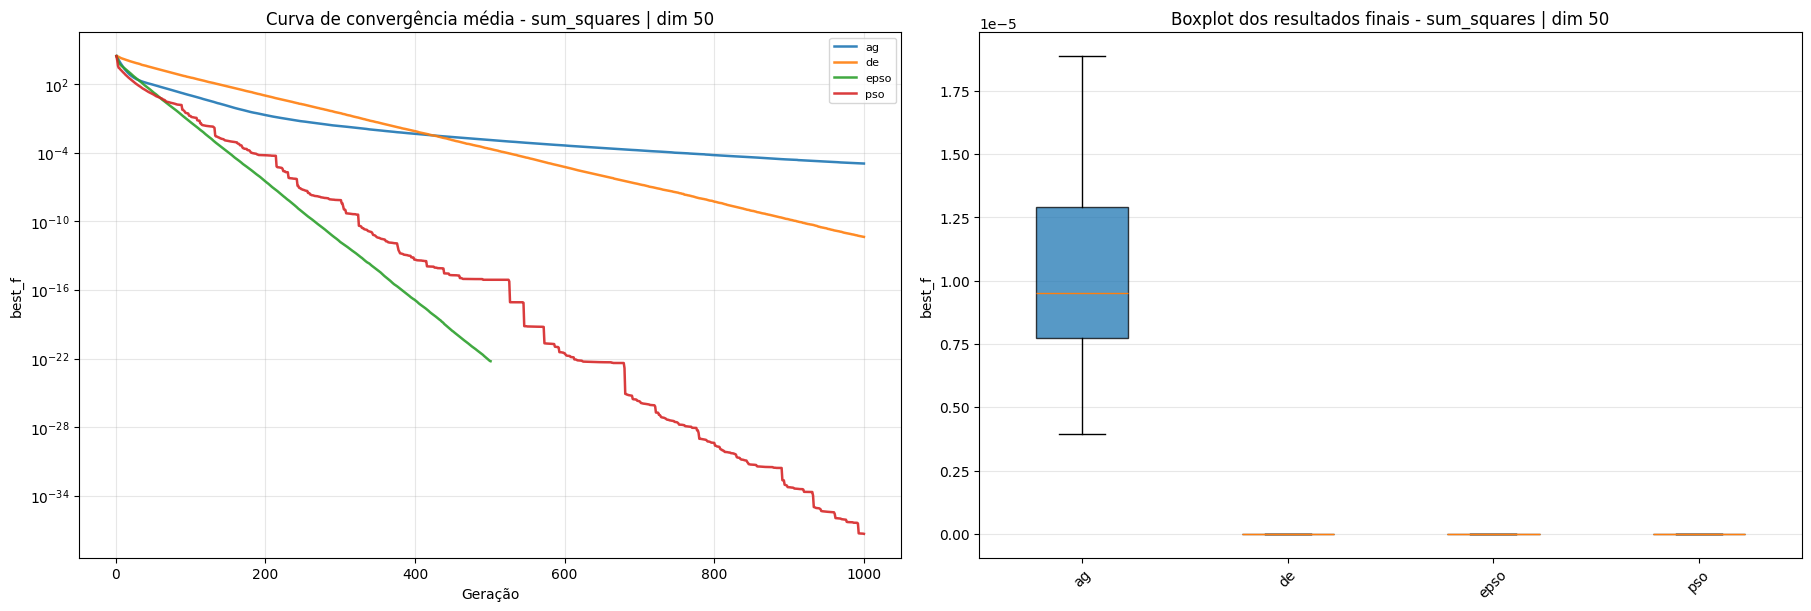

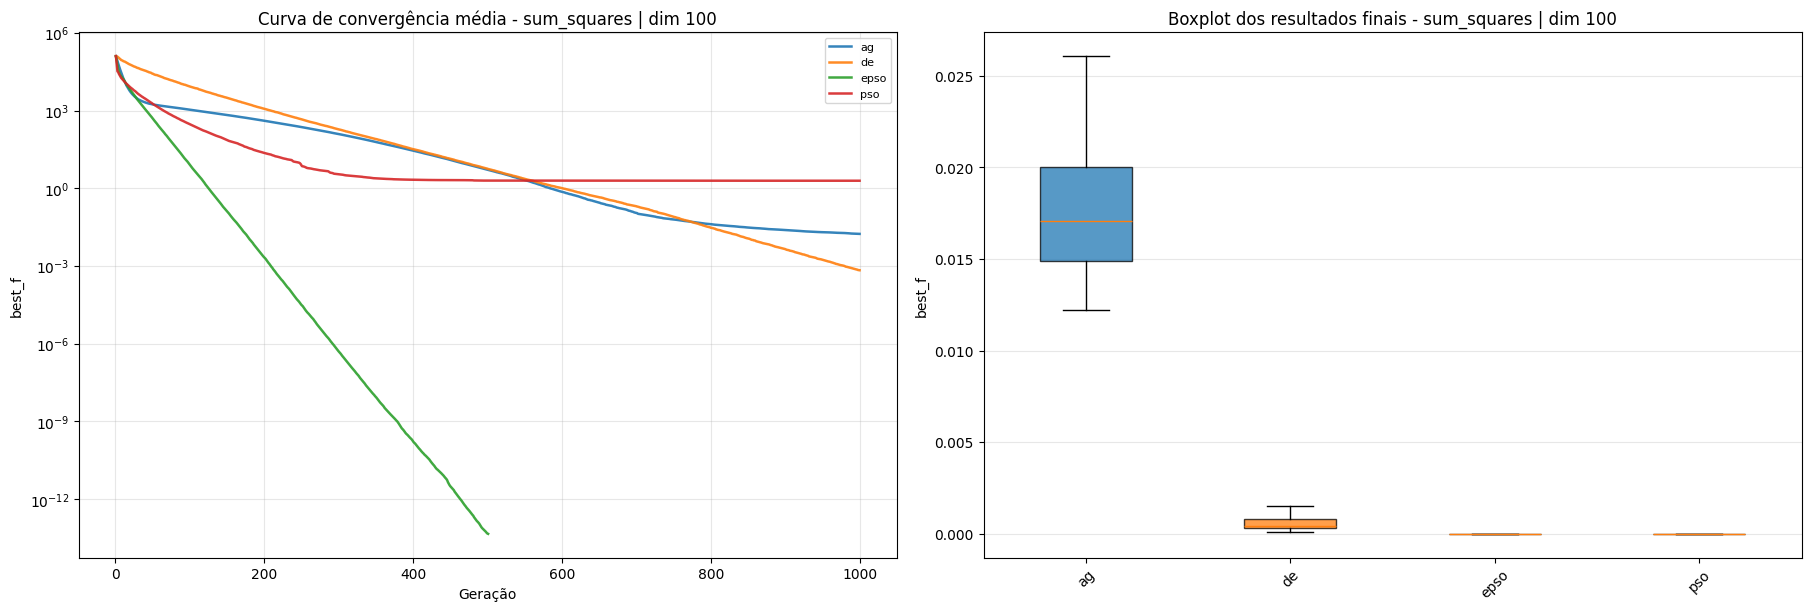

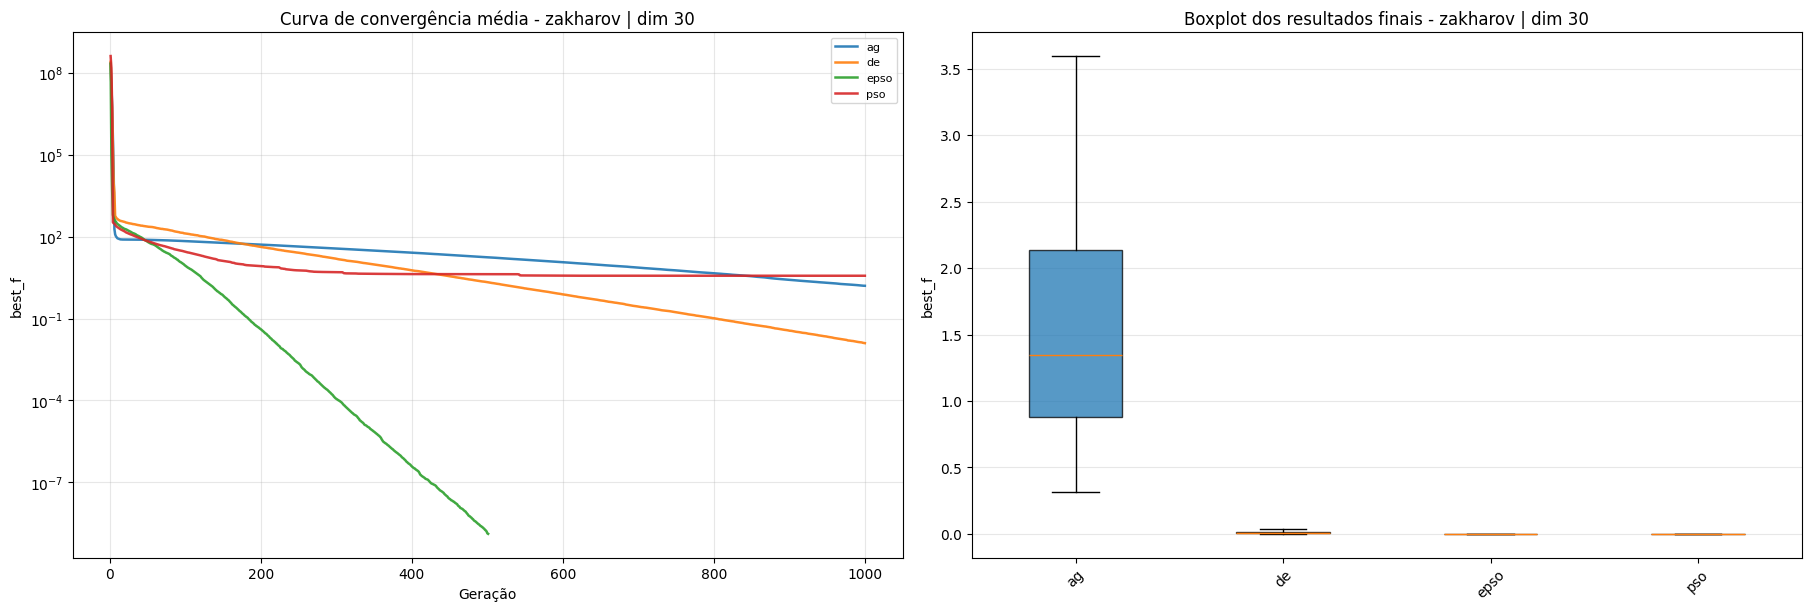

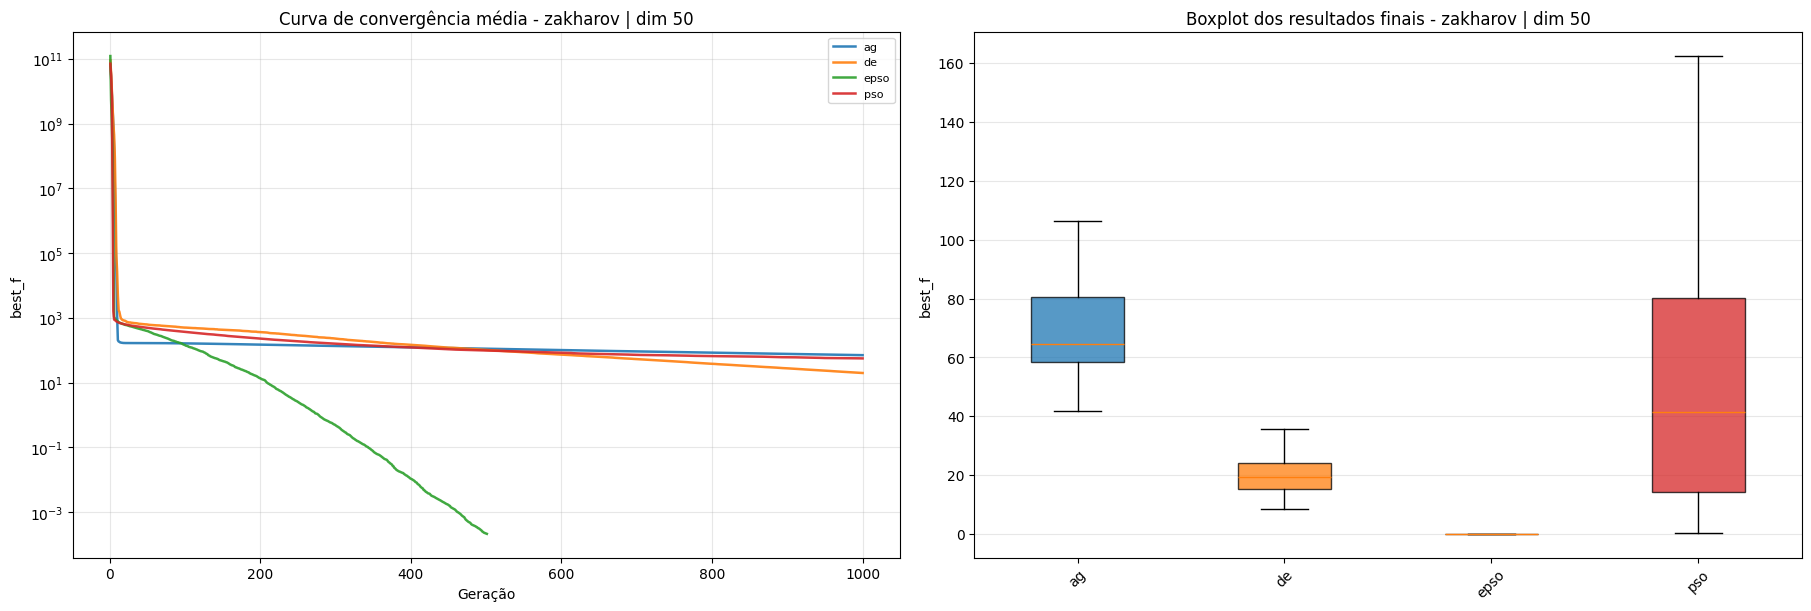

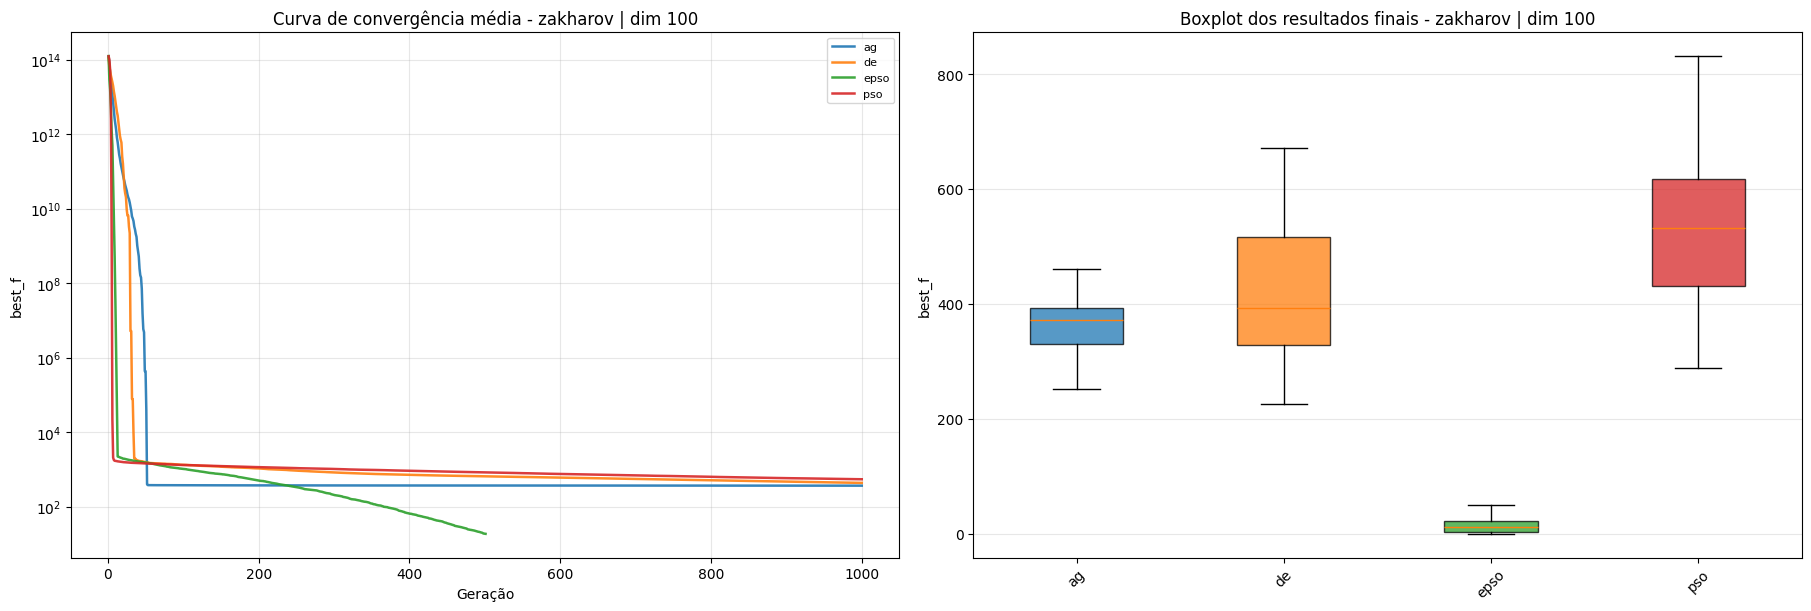

In [8]:
import matplotlib.pyplot as plt

funcoes = sorted(df_historico['funcao'].dropna().unique())

for funcao in funcoes:
    df_hist_funcao = df_historico[df_historico['funcao'] == funcao].copy()
    df_res_funcao = df_resultados[df_resultados['funcao'] == funcao].copy()
    dimensoes = sorted(df_hist_funcao['dim'].dropna().unique())
    algoritmos = sorted(df_hist_funcao['algoritmo'].dropna().unique())

    for dim in dimensoes:
        df_hist_par = df_hist_funcao[df_hist_funcao['dim'] == dim].copy()
        df_res_par = df_res_funcao[df_res_funcao['dim'] == dim].copy()
        if df_hist_par.empty or df_res_par.empty:
            continue

        convergencia_media = (
            df_hist_par
            .groupby(['algoritmo', 'geracao'], as_index=False)['best_f']
            .mean()
        )

        fig, eixos = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
        cores = plt.cm.tab10(range(max(1, len(algoritmos))))

        for indice, algoritmo in enumerate(algoritmos):
            dados = convergencia_media[convergencia_media['algoritmo'] == algoritmo]
            if dados.empty:
                continue
            eixos[0].plot(
                dados['geracao'],
                dados['best_f'],
                label=algoritmo,
                color=cores[indice % len(cores)],
                linewidth=1.8,
                alpha=0.9,
            )

        eixos[0].set_title(f'Curva de convergência média - {funcao} | dim {dim}')
        eixos[0].set_xlabel('Geração')
        eixos[0].set_ylabel('best_f')
        eixos[0].set_yscale('log')
        eixos[0].grid(True, alpha=0.3)
        eixos[0].legend(fontsize=8)

        dados_boxplot = []
        rotulos_boxplot = []
        cores_boxplot = []
        for indice, algoritmo in enumerate(algoritmos):
            valores = df_res_par[df_res_par['algoritmo'] == algoritmo]['best_f'].dropna().values
            if len(valores) == 0:
                continue
            dados_boxplot.append(valores)
            rotulos_boxplot.append(algoritmo)
            cores_boxplot.append(cores[indice % len(cores)])

        if dados_boxplot:
            box = eixos[1].boxplot(dados_boxplot, tick_labels=rotulos_boxplot, patch_artist=True, showfliers=False)
            for patch, cor in zip(box['boxes'], cores_boxplot):
                patch.set_facecolor(cor)
                patch.set_alpha(0.75)

        eixos[1].set_title(f'Boxplot dos resultados finais - {funcao} | dim {dim}')
        eixos[1].set_ylabel('best_f')
        eixos[1].grid(True, axis='y', alpha=0.3)
        eixos[1].tick_params(axis='x', rotation=45)

        plt.show()
        plt.close(fig)

#### Sum Squares

#### Dixon-Price

#### Sphere


#### Zakharov

### Multimodais